In [22]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')


In [23]:
# Data Download
df = yf.download('SPY', start='2016-01-01', end='2026-12-31',auto_adjust=False, interval='1d',multi_level_index=False)

# Cleaning Data
df.drop(columns=['Close','High','Low','Open','Volume'], inplace=True)
df.dropna(inplace=True)

# Model Training
window = 200
pred = []
dates = []
for i in range(window,len(df)):

    train = df['Adj Close'].iloc[i-window:i]

    model = ARIMA(train,order=(1,0,0)).fit()
    forecast = model.forecast(steps=1)

    pred.append(forecast.iloc[0])
    dates.append(df.index[i])


pred_series = pd.Series(pred,index = dates)
df['prediction'] = pred_series
df.dropna(inplace=True)


[*********************100%***********************]  1 of 1 completed


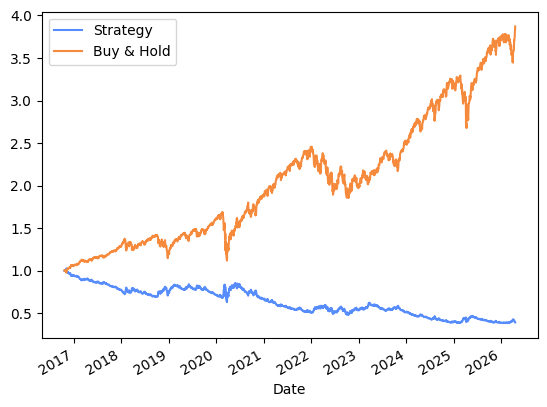

In [24]:
df['prev_close'] = df['Adj Close'].shift(1)

df['signal'] = 0

df.loc[df['prediction'] > df['prev_close'], 'signal'] = 1
df.loc[df['prediction'] < df['prev_close'], 'signal'] = -1

df['position'] = df['signal']

returns = df['Adj Close'].pct_change()
df['strategy_return'] = df['position'] * returns
strategy_cum = (1 + df['strategy_return']).cumprod()
buy_hold = (1 + returns).cumprod()

strategy_cum.plot(label='Strategy')
buy_hold.plot(label='Buy & Hold')
plt.legend()
plt.show()

print("Buy and Hold Returns",strategy_cum)


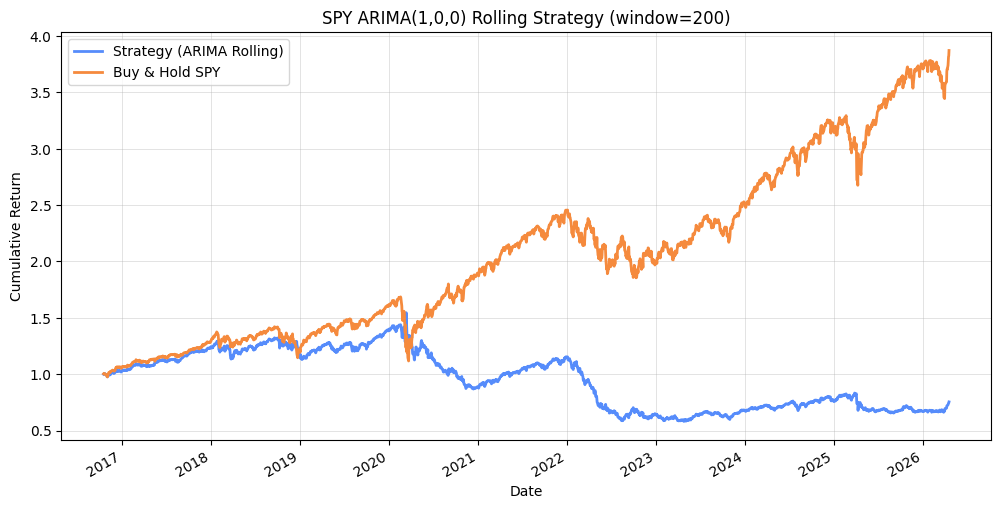


=== PERFORMANCE (2016-10-19 → 2026-04-17) ===
Strategy total return : -24.59%
Buy & Hold total return: 287.14%
Alpha vs Buy&Hold      : -311.73%
Strategy annualized    : -2.93%
Buy & Hold annualized  : 15.33%


In [28]:
import yfinance as yf
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# =========================
# DATA
# =========================
df = yf.download('SPY',
                 start='2016-01-01',
                 end='2026-12-31',
                 interval='1d',
                 auto_adjust=False,
                 progress=False)

df = df[['Adj Close']].copy()
df.dropna(inplace=True)

# Use log returns (better for ARIMA)
df['log_return'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))
df.dropna(inplace=True)

# =========================
# ROLLING ARIMA
# =========================
window = 200
forecasts = []
dates = []

for i in range(window, len(df)):
    train = df['log_return'].iloc[i - window:i]

    try:
        model = ARIMA(train, order=(1, 0, 0)).fit()
        forecast = model.forecast(steps=1).iloc[0]
    except:
        forecast = 0  # fallback if ARIMA fails

    forecasts.append(forecast)
    dates.append(df.index[i])

df['prediction'] = pd.Series(forecasts, index=dates)

# =========================
# SIGNAL GENERATION
# =========================
# Predict return direction
df['signal'] = 0
df.loc[df['prediction'] > 0, 'signal'] = 1
df.loc[df['prediction'] < 0, 'signal'] = -1

# IMPORTANT: trade next day → shift position
df['position'] = df['signal'].shift(1)

# =========================
# RETURNS
# =========================
df['asset_return'] = df['log_return']
df['strategy_return'] = df['position'] * df['asset_return']

df.dropna(inplace=True)

# Convert log returns → cumulative
strategy_cum = np.exp(df['strategy_return'].cumsum())
buy_hold_cum = np.exp(df['asset_return'].cumsum())

# =========================
# PLOT
# =========================
plt.figure(figsize=(12, 6))
strategy_cum.plot(label='Strategy (ARIMA Rolling)', linewidth=2)
buy_hold_cum.plot(label='Buy & Hold SPY', linewidth=2)

plt.title(f'SPY ARIMA(1,0,0) Rolling Strategy (window={window})')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

# =========================
# PERFORMANCE
# =========================
total_strategy = strategy_cum.iloc[-1] - 1
total_buyhold = buy_hold_cum.iloc[-1] - 1

print(f"\n=== PERFORMANCE ({df.index[0].date()} → {df.index[-1].date()}) ===")
print(f"Strategy total return : {total_strategy:.2%}")
print(f"Buy & Hold total return: {total_buyhold:.2%}")
print(f"Alpha vs Buy&Hold      : {total_strategy - total_buyhold:+.2%}")

# Annualized
days = (df.index[-1] - df.index[0]).days
years = days / 365.25

strat_annual = (1 + total_strategy) ** (1 / years) - 1
bh_annual = (1 + total_buyhold) ** (1 / years) - 1

print(f"Strategy annualized    : {strat_annual:.2%}")
print(f"Buy & Hold annualized  : {bh_annual:.2%}")